In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Data/prices.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Data/prices.csv'

Data Cleaning


In [ ]:
# print(df.duplicated().sum())
# print(df.isnull().sum())

df=df.dropna()
df=df.drop_duplicates()
print(df.head())

         date  item       city  price
0  2025-01-01  Rice  Kathmandu    120
1  2025-01-01  Rice  Bhaktapur    118
2  2025-01-01  Rice   Lalitpur    119
3  2025-01-01   Oil  Kathmandu    220
4  2025-01-01   Oil  Bhaktapur    215


In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df.head())

        date  item       city  price
0 2025-01-01  Rice  Kathmandu    120
1 2025-01-01  Rice  Bhaktapur    118
2 2025-01-01  Rice   Lalitpur    119
3 2025-01-01   Oil  Kathmandu    220
4 2025-01-01   Oil  Bhaktapur    215


Average Price per Item


In [ ]:
avg_price = df.groupby("item")["price"].mean()
print("\nAverage Price:\n", avg_price)


Average Price:
 item
Oil           232.666667
Rice          126.166667
Vegetables     85.000000
Name: price, dtype: float64


Inflation Trend (item-wise)

In [ ]:
trend = df.groupby(["date", "item"])["price"].mean().reset_index()

Visualization 1: Price Trend

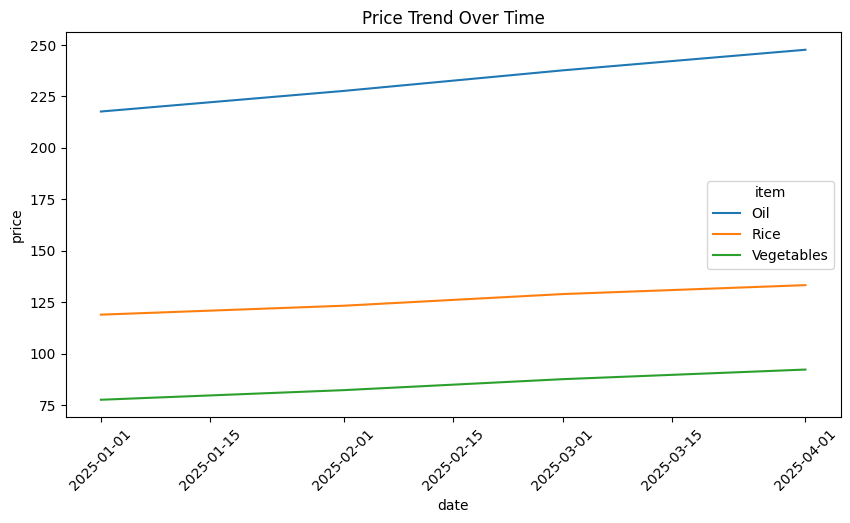

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=trend, x="date", y="price", hue="item")
plt.title("Price Trend Over Time")
plt.xticks(rotation=45)
plt.show()

Visualization 2: City Comparison

        city  price
0  Bhaktapur   1750
1  Kathmandu   1800
2   Lalitpur   1776


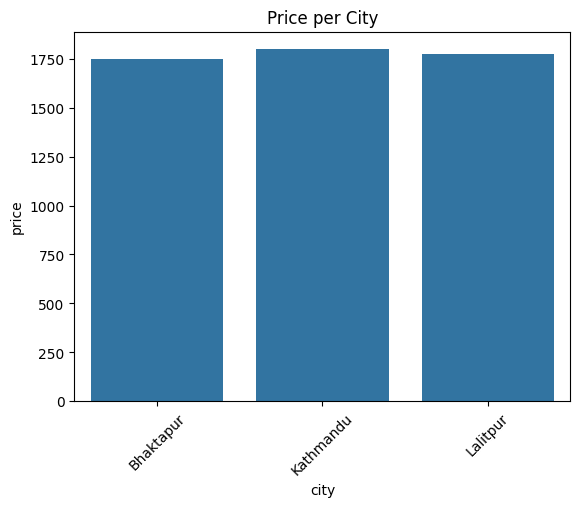

In [ ]:
city_price = df.groupby("city")["price"].sum().reset_index()
print(city_price)

sns.barplot(data=city_price, x="city", y="price")
plt.title("Price per City")
plt.xticks(rotation=45)
plt.show()

Visualization 3: Heatmap

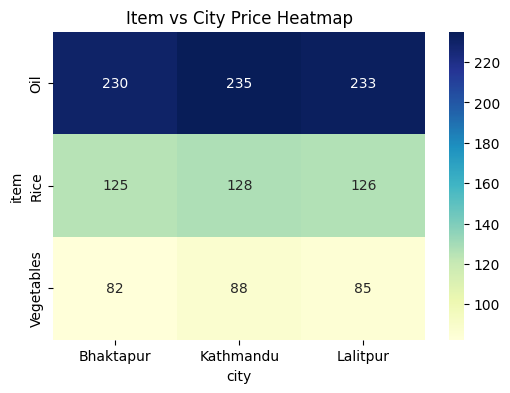

In [ ]:
pivot = df.pivot_table(values="price", index="item", columns="city", aggfunc="mean")

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu",fmt=".0f")
plt.title("Item vs City Price Heatmap")
plt.show()

Inflation Calculation

In [ ]:
df = df.sort_values("date")
df["pct_change"] = df.groupby("item")["price"].pct_change()*100

print("\nInflation (% change): \n" + df.to_string())


Inflation (% change): 
         date        item       city  price  pct_change
0  2025-01-01        Rice  Kathmandu    120         NaN
1  2025-01-01        Rice  Bhaktapur    118   -1.666667
2  2025-01-01        Rice   Lalitpur    119    0.847458
3  2025-01-01         Oil  Kathmandu    220         NaN
4  2025-01-01         Oil  Bhaktapur    215   -2.272727
5  2025-01-01         Oil   Lalitpur    218    1.395349
6  2025-01-01  Vegetables  Kathmandu     80         NaN
7  2025-01-01  Vegetables  Bhaktapur     75   -6.250000
8  2025-01-01  Vegetables   Lalitpur     78    4.000000
16 2025-02-01  Vegetables  Bhaktapur     80    2.564103
15 2025-02-01  Vegetables  Kathmandu     85    6.250000
14 2025-02-01         Oil   Lalitpur    228    4.587156
13 2025-02-01         Oil  Bhaktapur    225   -1.315789
17 2025-02-01  Vegetables   Lalitpur     82   -3.529412
11 2025-02-01        Rice   Lalitpur    123    3.361345
10 2025-02-01        Rice  Bhaktapur    122   -0.813008
9  2025-02-01        Ric

Clean Output


In [ ]:
df = df.dropna(subset=["pct_change"])
print(df)

         date        item       city  price  pct_change
1  2025-01-01        Rice  Bhaktapur    118   -1.666667
2  2025-01-01        Rice   Lalitpur    119    0.847458
4  2025-01-01         Oil  Bhaktapur    215   -2.272727
5  2025-01-01         Oil   Lalitpur    218    1.395349
7  2025-01-01  Vegetables  Bhaktapur     75   -6.250000
8  2025-01-01  Vegetables   Lalitpur     78    4.000000
16 2025-02-01  Vegetables  Bhaktapur     80    2.564103
15 2025-02-01  Vegetables  Kathmandu     85    6.250000
14 2025-02-01         Oil   Lalitpur    228    4.587156
13 2025-02-01         Oil  Bhaktapur    225   -1.315789
17 2025-02-01  Vegetables   Lalitpur     82   -3.529412
11 2025-02-01        Rice   Lalitpur    123    3.361345
10 2025-02-01        Rice  Bhaktapur    122   -0.813008
9  2025-02-01        Rice  Kathmandu    125    2.459016
12 2025-02-01         Oil  Kathmandu    230    2.222222
18 2025-03-01        Rice  Kathmandu    130    4.000000
19 2025-03-01        Rice  Bhaktapur    128   -1